# W5Act1 — 02 Exploratory Data Analysis

**Stage:** Data cleaning → EDA

Distributions first, relationships second. A correlation computed on a bimodal or heavily
skewed variable describes something other than what you think it does, which is why the
histograms come before the heatmap here.

> **This notebook is a stage template, not a mandatory step.** Use the notebooks your
> question needs and delete the rest — a descriptive project may never open
> `04_modeling.ipynb`, and a messy dataset may spend most of its life in `01`.
> See `CHECKLIST.md` for the full workflow.

In [1]:
import sys, pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.theme import PALETTE, save_fig, set_plot_style
set_plot_style()

# Point this at your file in data/raw/. Everything below follows from it.
DATASET = 'iris_clean.csv'

In [2]:
from src.data.loading import load_raw, save_processed
from src.data.cleaning import drop_exact_duplicates, snake_case_columns, strip_whitespace

df = load_raw(DATASET)

# Mechanical tidying — safe, reversible, no judgement involved.
df = snake_case_columns(strip_whitespace(df))

# Dataset-specific cleaning goes here, from what 01 found.
# 01_data_understanding found 3 exact duplicate rows — 2 extra copies of one
# Iris-setosa row (4.9, 3.1, 1.5, 0.1) and 1 extra copy of one Iris-virginica row
# (5.8, 2.7, 5.1, 1.9). Decision (DECISION notes in 01): these are an export
# artifact, not real repeated observations, so drop them.
df = drop_exact_duplicates(df)

save_processed(df, 'iris_clean.csv')
df.head()

dropped 3 duplicate row(s); 147 remain
wrote data/processed/iris_clean.csv  (147 rows)


,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
from src.analysis.descriptive import describe_categorical, describe_numeric

describe_numeric(df)

,count,missing,mean,std,variance,min,25%,50%,75%,max,range
sepal_length,147.0,0,5.8565,0.8291,0.6874,4.3,5.1,5.8,6.4,7.9,3.6
sepal_width,147.0,0,3.0558,0.4370,0.1910,2.0,2.8,3.0,3.3,4.4,2.4
petal_length,147.0,0,3.7803,1.7591,3.0945,1.0,1.6,4.4,5.1,6.9,5.9
petal_width,147.0,0,1.2088,0.7579,0.5744,0.1,0.3,1.3,1.8,2.5,2.4


In [4]:
describe_categorical(df)

,column,levels,missing,most_common,most_common_n,most_common_pct,top_5
0,class,3,0,Iris-versicolor,50,34.0,"Iris-versicolor (50), Iris-virginica (49), Iri..."


### Reading

_<Which variables are skewed? Which are near-constant? Does any mean sit far from its
median — and if so, is that skew or an outlier you decided to keep in 01?>_

saved outputs/figures/02_distributions.png


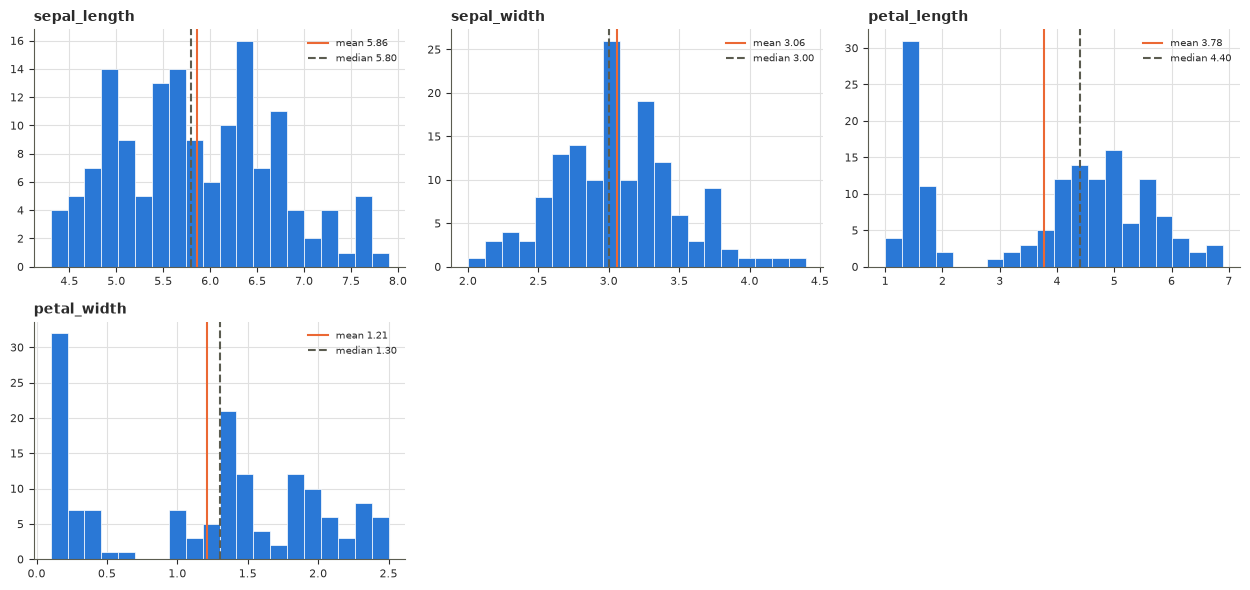

In [5]:
from src.visualization.plots import distribution_grid

fig, _ = distribution_grid(df)
save_fig(fig, '02_distributions')
plt.show()

## DECISION 4 — Pearson or Spearman?

The distributions above decide this, and the default everywhere else (Pearson) is often
the wrong tool.

- **Pearson** — linear relationships, interval data, sensitive to outliers and skew
- **Spearman** — monotonic relationships on ranks; robust to skew and outliers
- **Kendall** — rank-based, better for small n or many ties

- **Choice:** _<pearson / spearman / kendall>_ because _<what the histograms showed>_

saved outputs/figures/02_correlation.png


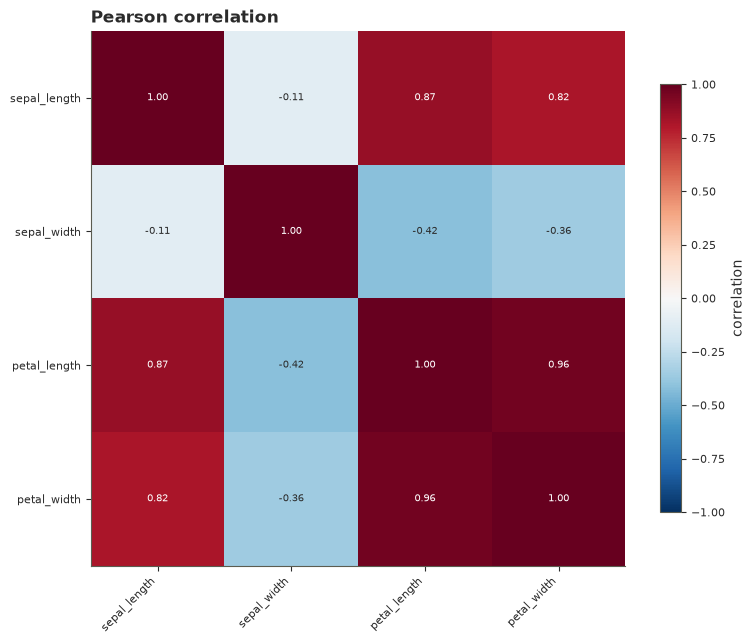

In [6]:
from src.analysis.correlation import correlation_matrix
from src.visualization.plots import correlation_heatmap

METHOD = 'pearson'   # <- set this from DECISION 4

corr = correlation_matrix(df, method=METHOD)
fig, _ = correlation_heatmap(corr, title=f'{METHOD.title()} correlation')
save_fig(fig, '02_correlation')
plt.show()

In [7]:
from src.analysis.correlation import top_correlations_with
from src.visualization.plots import correlation_bars

TARGET = None   # <- the column your question is about

if TARGET:
    top = top_correlations_with(df, TARGET, method=METHOD)
    display(top)
    fig, _ = correlation_bars(top, title=f'Correlation with {TARGET}')
    save_fig(fig, '02_target_correlation')
    plt.show()
else:
    print('Set TARGET to the column your question is about.')

Set TARGET to the column your question is about.


### Reading

_<Which relationships are strong enough to pursue, and which are strong but useless — a
proxy for the target, or collinear with a variable you already have? A ranked correlation
list is not a predictor shortlist.>_

In [8]:
from src.analysis.descriptive import group_compare
from src.visualization.plots import category_counts

GROUP = None   # <- a categorical column worth splitting by, if you have one

if GROUP:
    fig, _ = category_counts(df, GROUP)
    save_fig(fig, '02_group_counts')
    plt.show()
    display(group_compare(df, GROUP))
else:
    print('Set GROUP if a categorical split is relevant to your question.')

Set GROUP if a categorical split is relevant to your question.


## Findings so far

- _<what the data looks like, in two or three sentences>_
- _<the relationships worth taking to 03, and why>_
- _<what you have ruled out already>_

**Next stage:** _<03_analysis with a specific hypothesis / more cleaning / stop here if
description answers the question>_